In [ ]:
# Scratchpad

# Confirm translation happens one character at a time
# maybe start with just a simple NN?

In [361]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from datasets import load_dataset
import matplotlib.pyplot as plt
import random
import math

In [306]:
ds = load_dataset("Helsinki-NLP/opus_books", "en-it")['train']

In [307]:
ds.num_rows

32332

In [308]:
ds[0]

{'id': '0',
 'translation': {'en': 'Source: Project Gutenberg',
  'it': 'Source: www.liberliber.it/Audiobook available here'}}

In [309]:
it_full, en_full = [], []
for x in ds['translation']:
    if len(x['it']) > 600 or len(x['en']) > 600:
        continue
    it_full.append(x['it'])
    en_full.append(x['en'])

len(it_full), len(en_full)

(32009, 32009)

In [505]:
pad_token = '@'
bos_token = '^'
eos_token = '%'

vocab = set("".join(it_full + en_full))

# Adding extra tokens
vocab.add(pad_token)
vocab.add(bos_token)
vocab.add(eos_token)

vocab = sorted(list(vocab))
vocab_size = len(vocab)

print(f'vocab_size: {vocab_size}')
vocab

vocab_size: 125


[' ',
 '!',
 '"',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 ';',
 '?',
 '@',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 '[',
 ']',
 '^',
 '_',
 '`',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '{',
 '}',
 '£',
 '«',
 '°',
 '»',
 '½',
 'Ç',
 'È',
 'É',
 'à',
 'á',
 'â',
 'ä',
 'æ',
 'ç',
 'è',
 'é',
 'ê',
 'ë',
 'ì',
 'í',
 'î',
 'ï',
 'ò',
 'ó',
 'ô',
 'ù',
 'ü',
 'Œ',
 'œ',
 'Š',
 'š',
 '–',
 '—',
 '―',
 '‘',
 '’',
 '“',
 '”',
 '…']

In [506]:
stoi = { ch:i for i,ch in enumerate(vocab) }
itos = { i:ch for i,ch in enumerate(vocab) }
encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

pad_token_idx = stoi[padding_token]
bos_token_idx = stoi[bos_token]
eos_token_idx = stoi[eos_token]

print(encode('hi there'))
print(decode(encode('hi there')))

[65, 66, 0, 77, 65, 62, 75, 62]
hi there


In [312]:
split_index = int(0.9 * len(it_full))

it_train = [[stoi[c] for c in x] for x in it_full[:split_index]]
en_train = [[stoi[c] for c in x] for x in en_full[:split_index]]
it_eval = [[stoi[c] for c in x] for x in it_full[split_index:]]
en_eval = [[stoi[c] for c in x] for x in en_full[split_index:]]

print(f'it train length: {len(it_train)}')
print(f'en train length: {len(en_train)}')
print(f'it eval length: {len(it_eval)}')
print(f'en eval length: {len(en_eval)}')

it train length: 28808
en train length: 28808
it eval length: 3201
en eval length: 3201


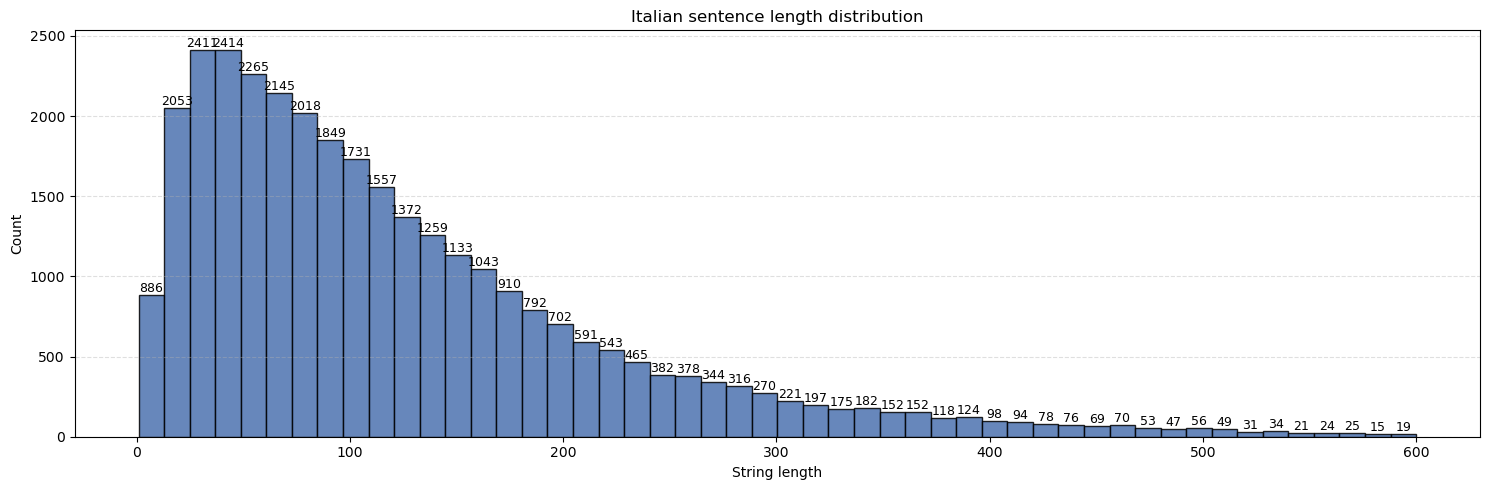

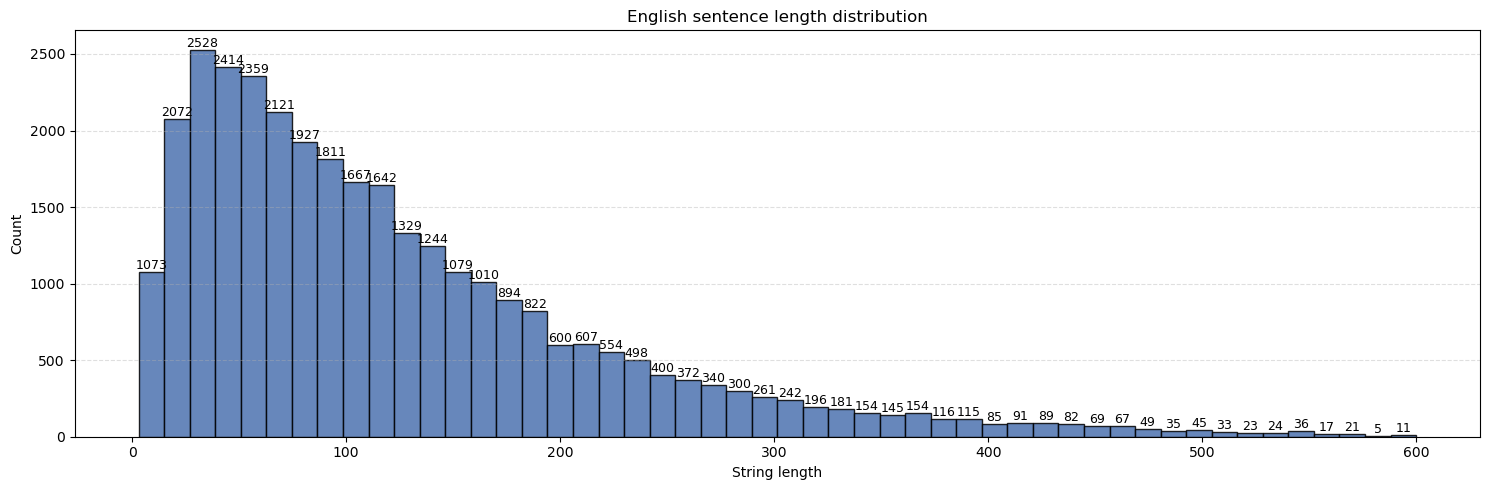

(<Figure size 1500x500 with 1 Axes>,
 <Axes: title={'center': 'English sentence length distribution'}, xlabel='String length', ylabel='Count'>)

In [313]:
def plot_length_distribution(strings, bins="auto", title="String Length Distribution"):
  lengths = [len(s) for s in strings]
  if not lengths:
      print("(no data)")
      return

  fig, ax = plt.subplots(figsize=(15, 5))
  counts, edges, _ = ax.hist(
      lengths, bins=bins, edgecolor="black", color="#4C72B0", alpha=0.85
  )

  ax.set_title(title)
  ax.set_xlabel("String length")
  ax.set_ylabel("Count")
  ax.grid(axis="y", linestyle="--", alpha=0.4)

  # Annotate each bar with its count.
  for count, left, right in zip(counts, edges[:-1], edges[1:]):
      if count:
          ax.text((left + right) / 2, count, int(count),
                  ha="center", va="bottom", fontsize=9)

  fig.tight_layout()
  plt.show()
  return fig, ax

plot_length_distribution(it_full, bins=50, title='Italian sentence length distribution')
plot_length_distribution(en_full, bins=50, title='English sentence length distribution')

In [350]:
# Batch generation

# Sorting on en as that's the translation target, and I want to minimise padding there
en_train_sorted_idx = sorted(range(len(en_train)), key=lambda i: len(en_train[i]))
en_eval_sorted_idx = sorted(range(len(en_train)), key=lambda i: len(en_train[i]))

batch_size = 30

def pad(ls):
    return nn.utils.rnn.pad_sequence(ls, batch_first=True, padding_value=padding_token_idx)

def generate_batch(dataset):
  it_data = it_train if dataset == 'train' else it_eval
  en_data = en_train if dataset == 'train' else en_eval
  sorted_idx = en_train_sorted_idx if dataset == 'train' else en_eval_sorted_idx

  idx_start = random.randint(0, len(it_data) - batch_size)
  idxs = sorted_idx[idx_start:idx_start+batch_size]

  it_x = pad([torch.tensor(it_data[x]) for x in idxs])

  bos = torch.tensor([bos_token_idx])
  eos = torch.tensor([eos_token_idx])
  en_seqs = [torch.tensor(en_data[x]) for x in idxs]
  en_x = pad([torch.cat([bos, s]) for s in en_seqs])
  en_y = pad([torch.cat([s, eos]) for s in en_seqs])

  return it_x, en_x, en_y
    
it_x, en_x, en_y = generate_batch('train')

it_x.shape, en_x.shape, en_y.shape

# for i in range(batch_size):
#     print(decode(it_x[i].tolist()))
#     print(decode(en_x[i].tolist()))
#     print(decode(en_y[i].tolist()))

(torch.Size([30, 173]), torch.Size([30, 125]), torch.Size([30, 125]))

In [623]:
# Hyperparameters
d_model=512
d_hid=4*d_model
max_len=600
n_head = 4
d_head = d_model // n_head
n_stack = 2
p_dropout = 0.1

assert d_model % n_head == 0
# ---------------

In [629]:
class PositionalEncoding(nn.Module):

    def __init__(self):
        super().__init__()
        # Pre-generate lookup table
        pe_len = max_len + 1 # Accounts for adding bos / eos
        pe = torch.zeros(pe_len, d_model)
        pos = torch.arange(pe_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div_term)
        pe[:, 1::2] = torch.cos(pos * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)   # (1, max_len + 1, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class AttentionHead(nn.Module):

    def __init__(self):
        super().__init__()
        self.q_wei = nn.Linear(d_model, d_head, bias=False)
        self.k_wei = nn.Linear(d_model, d_head, bias=False)
        self.v_wei = nn.Linear(d_model, d_head, bias=False)
        mask_len = max_len + 1 # Accounts for adding bos / eos
        self.register_buffer('causal_mask', torch.tril(torch.ones(mask_len, mask_len)) == 0)

    def forward(self, q_x, kv_x, pad_mask, apply_causal_mask=False):
        q = self.q_wei(q_x)
        k = self.k_wei(kv_x)
        v = self.v_wei(kv_x)

        out = (q @ k.transpose(-1, -2))/d_head**0.5
        out = out.masked_fill(pad_mask, float('-inf'))
        if apply_causal_mask:
            q_len = q_x.shape[1]
            k_len = kv_x.shape[1]
            out = out.masked_fill(self.causal_mask[:q_len,:k_len], float('-inf'))
        out = F.softmax(out, dim=-1)
        out = out @ v

        return out


class MultiHeadAttention(nn.Module):

    def __init__(self):
        super().__init__()
        self.heads = nn.ModuleList(AttentionHead() for i in range(n_head)) # Can likely optimise by running in parallel as a single big matrix
        self.linear = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(p_dropout)

    def forward(self, q_x, kv_x, pad_mask, apply_causal_mask=False):
        out = [head(q_x, kv_x, pad_mask, apply_causal_mask) for head in self.heads]
        out = torch.cat(out, dim=-1)
        out = self.linear(out)
        out = self.dropout(out)
        return out


class FeedForward(nn.Module):

    def __init__(self):
        super().__init__()
        self.lin1 = nn.Linear(d_model, d_hid)
        self.relu = nn.ReLU()
        self.lin2 = nn.Linear(d_hid, d_model)
        self.dropout = nn.Dropout(p_dropout)

    def forward(self, x):
        out = self.lin1(x)
        out = self.relu(out)
        out = self.lin2(out)
        out = self.dropout(out)
        return out


class EncoderStack(nn.Module):

    def __init__(self):
        super().__init__()
        self.attn = MultiHeadAttention()
        self.ln1 = nn.LayerNorm(d_model)
        self.ffw = FeedForward()
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x, pad_mask):
        out = self.ln1(x + self.attn(x, x, pad_mask))
        out = self.ln2(out + self.ffw(out))
        return out


class DecoderStack(nn.Module):

    def __init__(self):
        super().__init__()
        self.attn = MultiHeadAttention()
        self.ln1 = nn.LayerNorm(d_model)
        self.cross_attn = MultiHeadAttention()
        self.ln2 = nn.LayerNorm(d_model)
        self.ffw = FeedForward()
        self.ln3 = nn.LayerNorm(d_model)

    def forward(self, trs_x, pad_mask_trs_x, src_out, pad_mask_src_x):
        out = self.ln1(trs_x + self.attn(trs_x, trs_x, pad_mask_trs_x, apply_causal_mask=True))
        out = self.ln2(out + self.cross_attn(out, src_out, pad_mask_src_x))
        out = self.ln3(out + self.ffw(out))
        return out


class AttentionReplica(nn.Module):

    def __init__(self):
        super().__init__()
        self.emb_table = nn.Embedding(vocab_size, d_model, padding_idx=pad_token_idx)
        self.pos_enc = PositionalEncoding()

        self.encoder = nn.ModuleList([EncoderStack() for _ in range(n_stack)])
        self.enc_dropout = nn.Dropout(p_dropout)

        self.decoder = nn.ModuleList([DecoderStack() for _ in range(n_stack)])
        self.dec_dropout = nn.Dropout(p_dropout)

        self.linear = nn.Linear(d_model, vocab_size)

    def forward(self, src_x, trs_x):

        pad_mask_src_x = (src_x == pad_token_idx).unsqueeze(-2)
        pad_mask_trs_x = (trs_x == pad_token_idx).unsqueeze(-2)

        # Encoder
        src_out = self.emb_table(src_x) * math.sqrt(d_model)
        src_out = self.pos_enc(src_out)
        src_out = self.enc_dropout(src_out)
        for encoderStack in self.encoder:
            src_out = encoderStack(src_out, pad_mask_src_x)

        trs_out = self.emb_table(trs_x) * math.sqrt(d_model)
        trs_out = self.pos_enc(trs_out)
        trs_out = self.dec_dropout(trs_out)
        for decoderStack in self.decoder:
            trs_out = decoderStack(trs_out, pad_mask_trs_x, src_out, pad_mask_src_x)

        trs_out = self.linear(trs_out)
        return trs_out

In [630]:
torch.manual_seed(1337)
random.seed(1337)

m = AttentionReplica()

warmup = 4000
def lr_lambda(step):
    step = max(step, 1)
    return d_model**-0.5 * min(step**-0.5, step * warmup**-1.5)

optimizer = torch.optim.AdamW(m.parameters(), lr=1.0, betas=(0.9, 0.98))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

for iter in range(10):
    it_x, en_x, en_y = generate_batch('train')
    
    logits = m(it_x, en_x)
    print(f'logits.shape: {logits.shape}, en_y.shape: {en_y.shape}')
    B, T, E = logits.shape
    loss = F.cross_entropy(logits.view(B*T, E), en_y.view(B*T), ignore_index=pad_token_idx, label_smoothing=0.1)
    print(f'loss: {loss}')
    
    loss.backward()
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad(set_to_none=True)

logits.shape: torch.Size([30, 154, 125]), en_y.shape: torch.Size([30, 154])
loss: 4.9475274085998535
logits.shape: torch.Size([30, 125, 125]), en_y.shape: torch.Size([30, 125])
loss: 4.969781398773193
logits.shape: torch.Size([30, 197, 125]), en_y.shape: torch.Size([30, 197])
loss: 4.955427646636963
logits.shape: torch.Size([30, 82, 125]), en_y.shape: torch.Size([30, 82])
loss: 4.943032264709473
logits.shape: torch.Size([30, 137, 125]), en_y.shape: torch.Size([30, 137])
loss: 4.961440563201904
logits.shape: torch.Size([30, 142, 125]), en_y.shape: torch.Size([30, 142])
loss: 4.9364495277404785
logits.shape: torch.Size([30, 212, 125]), en_y.shape: torch.Size([30, 212])
loss: 4.932816505432129
logits.shape: torch.Size([30, 42, 125]), en_y.shape: torch.Size([30, 42])
loss: 4.9301862716674805
logits.shape: torch.Size([30, 247, 125]), en_y.shape: torch.Size([30, 247])
loss: 4.917593479156494
logits.shape: torch.Size([30, 313, 125]), en_y.shape: torch.Size([30, 313])
loss: 4.926328659057617


In [614]:
torch.manual_seed(1337)
random.seed(1337)

m = AttentionReplica()

it_x, en_x, en_y = generate_batch('train')

print(f'it_x.shape: {it_x.shape}')
print(f'en_x.shape: {en_x.shape}')
print(f'en_y.shape: {en_y.shape}')

logits = m(it_x, en_x)
print(f'logits.shape: {logits.shape}')

it_x.shape: torch.Size([30, 224])
en_x.shape: torch.Size([30, 154])
en_y.shape: torch.Size([30, 154])
logits.shape: torch.Size([30, 154, 125])


In [363]:
# Positional encoding scratchpad

pe = torch.zeros(max_len, d_model)
pos = torch.arange(max_len).unsqueeze(1)
div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
pe[:, 0::2] = torch.sin(pos * div_term)
pe[:, 1::2] = torch.cos(pos * div_term)
pe.unsqueeze(0).shape

torch.Size([1, 600, 512])

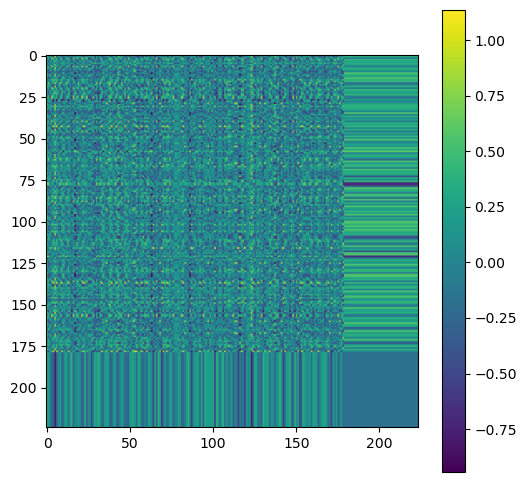

torch.Size([30, 224])
torch.Size([30, 1, 224])


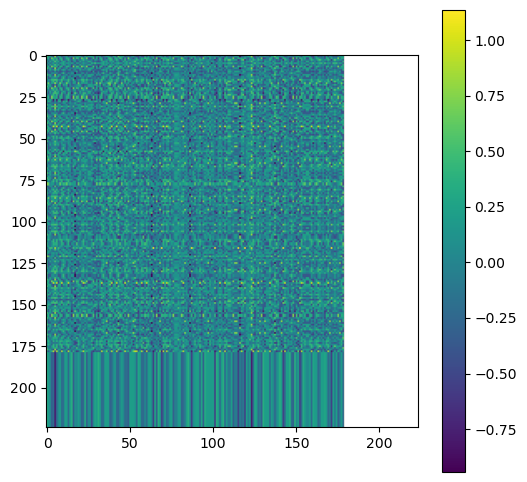

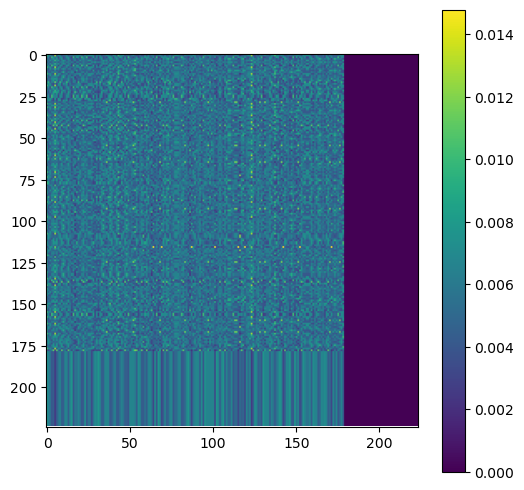

torch.Size([30, 224, 128])


In [513]:
# Single attention head scratchpad
torch.manual_seed(1337)

def plot_qk(qk):
    plt.figure(figsize=(6, 6))
    plt.imshow(qk.detach().cpu().numpy())
    plt.colorbar()
    plt.show()

emb_table = nn.Embedding(vocab_size, d_model)

q_wei = nn.Linear(d_model, d_head)
k_wei = nn.Linear(d_model, d_head)
v_wei = nn.Linear(d_model, d_head) # Fix d_v = d_k = d_head

it_proc = emb_table(it_x)

k = k_wei(it_proc)
q = q_wei(it_proc)
v = v_wei(it_proc)

out = (q @ k.transpose(-1, -2))/d_head**0.5
plot_qk(out[0])

pad_mask = (it_x == pad_token_idx)
print(pad_mask.shape)
print(pad_mask.unsqueeze(-2).shape)
out = out.masked_fill(pad_mask.unsqueeze(-2), float('-inf'))
plot_qk(out[0])

out = F.softmax(out, dim=-1)
plot_qk(out[0])

out = out @ v
print(out.shape)

In [439]:
# print(torch.tril(torch.ones(5, 5)))
# print(F.softmax(torch.tril(torch.ones(5, 5)), dim=1))

tril = torch.tril(torch.ones(5, 5)).masked_fill(torch.tril(torch.ones(5, 5)) == 0, float('-inf'))
print(tril)
print(F.softmax(tril, dim=-1))

tensor([[1., -inf, -inf, -inf, -inf],
        [1., 1., -inf, -inf, -inf],
        [1., 1., 1., -inf, -inf],
        [1., 1., 1., 1., -inf],
        [1., 1., 1., 1., 1.]])
tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000],
        [0.3333, 0.3333, 0.3333, 0.0000, 0.0000],
        [0.2500, 0.2500, 0.2500, 0.2500, 0.0000],
        [0.2000, 0.2000, 0.2000, 0.2000, 0.2000]])


In [496]:
scores = torch.ones_like(out)
pad_mask = (it_x == padding_token_idx)
scores = scores.masked_fill(pad_mask.unsqueeze(-2), float('-inf'))
scores

tensor([[[1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         ...,
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf]],

        [[1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.],
         [1., 1., 1.,  ..., 1., 1., 1.]],

        [[1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         ...,
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf]],

        ...,

        [[1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, -inf, -inf],
         [1., 1., 1.,  ..., -inf, 

In [522]:
out = [torch.ones((4, 3, 2)) for _ in range(4)]
print(out)
torch.cat(out, dim=-1).shape

[tensor([[[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]]]), tensor([[[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]]]), tensor([[[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]]]), tensor([[[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]],

        [[1., 1.],
         [1., 1.],
         [1., 1.]]])]


torch.Size([4, 3, 8])

In [555]:
torch.tril(torch.ones(10, 10)) == 0

tensor([[False,  True,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False,  True,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False,  True,  True,  True,  True,  True,  True,  True],
        [False, False, False, False,  True,  True,  True,  True,  True,  True],
        [False, False, False, False, False,  True,  True,  True,  True,  True],
        [False, False, False, False, False, False,  True,  True,  True,  True],
        [False, False, False, False, False, False, False,  True,  True,  True],
        [False, False, False, False, False, False, False, False,  True,  True],
        [False, False, False, False, False, False, False, False, False,  True],
        [False, False, False, False, False, False, False, False, False, False]])